# Two-cell $[-45]$ anisotropic tube (ASC paper)

A **two-cell** curved tube with a single $[-45^\circ]$ anisotropic ply and an internal web — the
multi-cell composite benchmark from the ASC paper (*bagla2025asc*). It exercises everything at once:
anisotropy (ext–twist coupling), curvature, **and** a multi-cell junction. We compute all three models
(KL, RM, JAX-solid) from their YAMLs and benchmark the shell models against the 2-D solid.

In [1]:
import os, sys, time
import numpy as np
CC = r"C:\Users\bagla0\OneDrive - purdue.edu\2026_195\Claude_code"
for p in ("", "opensg_jax"):
    sys.path.insert(0, os.path.join(CC, p))
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import jax; jax.config.update("jax_enable_x64", True)
np.set_printoptions(precision=4, linewidth=160, suppress=True)
from IPython.display import Image
from fe_jax.orient_plot import plot_orient
LBL = ["EA", "GA2", "GA3", "GJ", "EI2", "EI3"]
def sym(M):
    M = np.asarray(M, dtype=float); return 0.5 * (M + M.T)
def pcterr(C, S):
    # all nonzero terms; neglect (->0) any term >=1000x below the max |term| in the reference
    C, S = sym(C), sym(S); thr = np.max(np.abs(S)) / 1000.0; out = np.zeros((6, 6))
    for i in range(6):
        for j in range(6):
            out[i, j] = 100.0 * (C[i, j] - S[i, j]) / S[i, j] if abs(S[i, j]) >= thr else 0.0
    return out
def diag_table(name, C, S):
    C, S = sym(C), sym(S)
    print("  %-5s %15s %15s %12s" % ("term", name, "benchmark", "%err"))
    for i in range(6):
        print("  %-5s %15.5e %15.5e %+11.4f" % (LBL[i], C[i, i], S[i, i], 100.0*(C[i,i]-S[i,i])/S[i,i]))
def parse_vabs(path):
    lines = open(path).read().splitlines()
    i = next(k for k, l in enumerate(lines) if "Timoshenko Stiffness Matrix" in l)
    rows = []
    for l in lines[i + 1:]:
        q = l.split()
        if len(q) == 6:
            try: rows.append([float(x) for x in q])
            except ValueError: continue
        if len(rows) == 6: break
    return np.array(rows)
def wall_t(meshp):
    import yaml
    d = yaml.safe_load(open(meshp)); return sum(float(p[1]) for p in d["sections"][0]["layup"])
print("ready | jax", jax.__version__)

ready | jax 0.9.2


In [2]:
SHELL = os.path.join(CC, "tests", "research", "multicell_tube", "data", "tube2cell_aniso_thin.yaml")
SOLIDY = os.path.join(CC, "tests", "research", "multicell_tube", "data", "solid_tube2cell_aniso_thin.yaml")
BENCH = os.path.join(CC, "tests", "research", "multicell_tube", "data", "C6_solid_tube2cell_aniso_thin.txt")
print("shell YAML :", os.path.basename(SHELL), os.path.exists(SHELL))
print("solid YAML :", os.path.basename(SOLIDY), os.path.exists(SOLIDY))
print("benchmark  :", os.path.basename(BENCH), os.path.exists(BENCH))

shell YAML : tube2cell_aniso_thin.yaml True
solid YAML : solid_tube2cell_aniso_thin.yaml True
benchmark  : C6_solid_tube2cell_aniso_thin.txt True


## Material orientation (solid + shell)

The two cells share the internal web; $e_2$ (blue) follows the $[-45]$ ply flow.

[orient_plot] SHELL: e3 OML->IML 222/240   e1_z mean=1.000


[orient_plot] SOLID: e3 OML->IML 376/450   e1_z mean=0.707


[orient_plot] wrote C:\Users\bagla0\OneDrive - purdue.edu\2026_195\Claude_code\docs\tutorials\_img\twocell_m45_orient.png


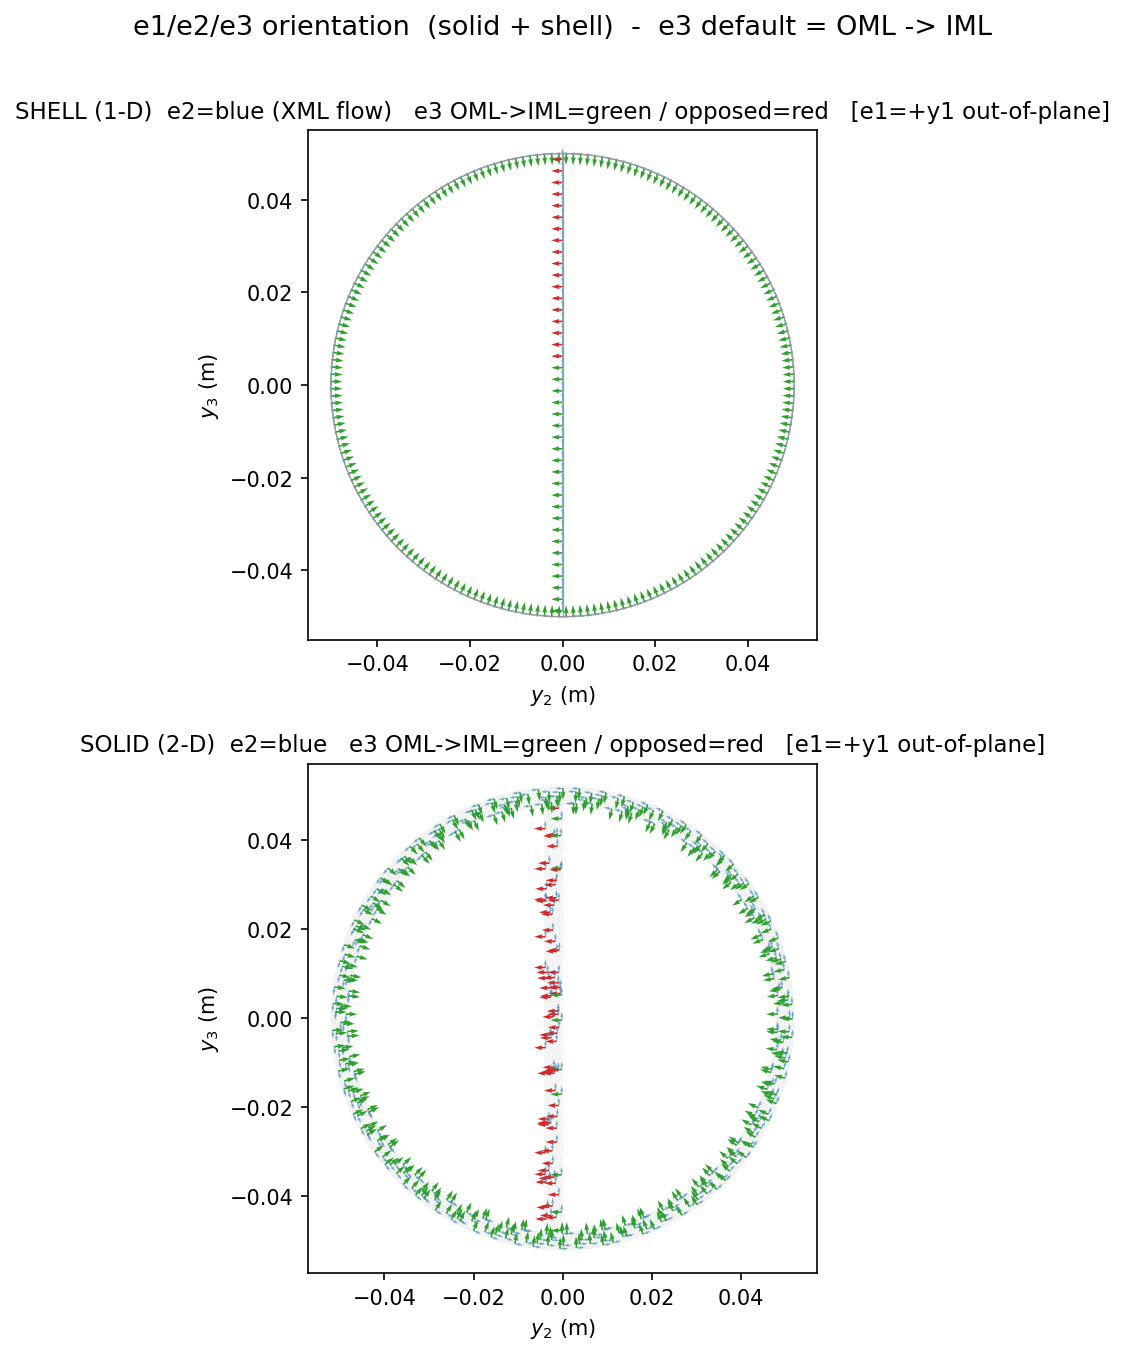

In [3]:
png = plot_orient(SHELL, SOLIDY, out_png=os.path.join(r"C:\Users\bagla0\OneDrive - purdue.edu\2026_195\Claude_code\docs\tutorials\_img", "twocell_m45_orient.png"))
Image(filename=png)

## KL, RM, and JAX-solid 6×6

In [4]:
from opensg_jax.fe_jax.strip_RM import rm_timoshenko_6x6
from opensg_jax.fe_jax.gradient_kirchhoff import gradient_junction_kirchhoff
from opensg_jax.fe_jax.solid_timo import compute_timo_from_yaml
T = wall_t(SHELL)
S = sym(np.loadtxt(BENCH))                                              # FEniCS 2-D solid reference
C_kl = sym(gradient_junction_kirchhoff(SHELL, frac=0.0, dshift=T/2)[0])
C_rm = sym(rm_timoshenko_6x6(SHELL, 0.0, dshift=T/2, curved=True, shear="mitc"))
C_jx = sym(compute_timo_from_yaml(SOLIDY, verbose=False))               # JAX 2-D solid
print("JAX 2-D solid Timoshenko 6x6:")
print(C_jx)

[orient_plot] SHELL: e3 OML->IML 222/240   e1_z mean=1.000


[orient_plot] wrote C:\Users\bagla0\OneDrive - purdue.edu\2026_195\Claude_code\tests\research\multicell_tube\data\tube2cell_aniso_thin_orient_e1e2e3.png


JAX 2-D solid Timoshenko 6x6:
[[20008055.5735       -5.5777 -1197608.8545  -209152.0089       -0.1604     8760.4383]
 [      -5.5777  4487963.1568        3.0066        0.7066   104489.7966        0.0026]
 [-1197608.8545        3.0066  7334750.2903    -5845.9013        0.0224   101256.2475]
 [ -209152.0089        0.7066    -5845.9013    23570.0891        0.0091        3.3158]
 [      -0.1604   104489.7966        0.0224        0.0091    22481.6441        0.0009]
 [    8760.4383        0.0026   101256.2475        3.3158        0.0009    19222.4566]]


## Benchmark — KL vs RM vs JAX-solid, against the 2-D solid reference

In [5]:
print("  %-5s %14s %14s %14s %14s" % ("term", "KL", "RM", "JAX-solid", "ref-solid"))
for i in range(6):
    print("  %-5s %14.5e %14.5e %14.5e %14.5e" % (LBL[i], C_kl[i,i], C_rm[i,i], C_jx[i,i], S[i,i]))
print("\n  %-5s %10s %10s %10s" % ("term", "KL%err", "RM%err", "JAXsol%err"))
for i in range(6):
    print("  %-5s %+9.2f %+9.2f %+9.4f" % (LBL[i],
        100*(C_kl[i,i]-S[i,i])/S[i,i], 100*(C_rm[i,i]-S[i,i])/S[i,i], 100*(C_jx[i,i]-S[i,i])/S[i,i]))

  term              KL             RM      JAX-solid      ref-solid
  EA       2.01973e+07    2.02101e+07    2.00081e+07    2.00081e+07
  GA2      3.86895e+06    4.43798e+06    4.48796e+06    4.48796e+06
  GA3      6.51352e+06    7.32376e+06    7.33475e+06    7.33475e+06
  GJ       2.34761e+04    2.34945e+04    2.35701e+04    2.35700e+04
  EI2      2.25629e+04    2.28663e+04    2.24816e+04    2.24820e+04
  EI3      1.90291e+04    1.91760e+04    1.92225e+04    1.92220e+04

  term      KL%err     RM%err JAXsol%err
  EA        +0.95     +1.01   -0.0000
  GA2      -13.79     -1.11   +0.0000
  GA3      -11.20     -0.15   +0.0000
  GJ        -0.40     -0.32   +0.0004
  EI2       +0.36     +1.71   -0.0016
  EI3       -1.00     -0.24   +0.0024


## Takeaway

On the two-cell $[-45]$ tube the JAX 2-D solid sits on the reference, and across the multi-cell junction
**RM keeps the transverse-shear terms $GA_2,GA_3$ much closer to the solid than KL** — the multi-cell
composite result reported in the ASC paper. When the walls thicken or a soft core appears, fall back to
the 2-D solid (see the {doc}`../theory/reissner_mindlin` regime note).